In [1]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt

#### Dependencies ####
import logging
import sys
import time
import joblib
import torch
from cvxopt import matrix, solvers # Only necessary for the stacked model.
from pydiffmap import diffusion_map as dm
import time
import argparse
import os
from sklearn.metrics import r2_score
import pdb
from tqdm import tqdm
import json
import os

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
logger.info("hi")

# Repository imports
from ridge_utils.ridge import bootstrap_ridge_with_y_projection
import ridge_utils.npp
from ridge_utils.util import make_delayed
from ridge_utils.dsutils import make_word_ds

from manifold_utils.projection import down_project, get_up_projection_map, get_up_projections_torch
from manifold_utils.algorithms import *
from manifold_utils.constants import *
from manifold_utils.feature_extraction import FeatureExtractor

INFO:__main__:hi


In [2]:
# COPY-PASTE
MODEL = 'opt-125m'
IDS = {'id': [7.936793171868141,
  9.728818703813252,
  11.255028891973575,
  14.14994763279517,
  18.098005132324317,
  20.440036269653557,
  22.29363806453739,
  23.085284115735334,
  23.411288996173493,
  23.118665186357862,
  22.939806040557038,
  21.221942675521152],
 'std': [0.2445633365705514,
  0.3608839329521785,
  0.6868267839674871,
  1.169528648319596,
  0.43424643011631797,
  0.3877205640992098,
  0.3368020081049373,
  0.4409718488614193,
  0.14478498543476584,
  0.11648665000476488,
  0.12506912462286923,
  0.33238907526124234],
 'pca': [680.4,
  679.6,
  690.4,
  699.6,
  708.2,
  711.0,
  711.0,
  713.6,
  715.0,
  715.8,
  713.4,
  714.6],
 'pca_std': [1.019803902718557,
  0.8,
  0.48989794855663565,
  0.48989794855663565,
  0.4000000000000001,
  0.0,
  0.0,
  0.48989794855663565,
  0.0,
  0.4000000000000001,
  0.48989794855663565,
  0.48989794855663565],
 'pr': [38.559391657370995,
  55.09232799426633,
  78.49358409789876,
  97.09373953411082,
  125.86039090045563,
  151.35378024182484,
  170.5567629895764,
  174.96519588354371,
  171.99447347386734,
  140.16809608093777,
  107.4329648987778,
  94.99329240234555],
 'pr_std': [0.8076078510428113,
  1.0821834227473304,
  1.396902043590509,
  1.6365728693424513,
  1.6773453011985622,
  1.4483362813033105,
  1.2192600957361053,
  1.0555636561775061,
  1.0134541689083534,
  1.0910489907945826,
  0.9576563132409327,
  1.1788416131687391]}


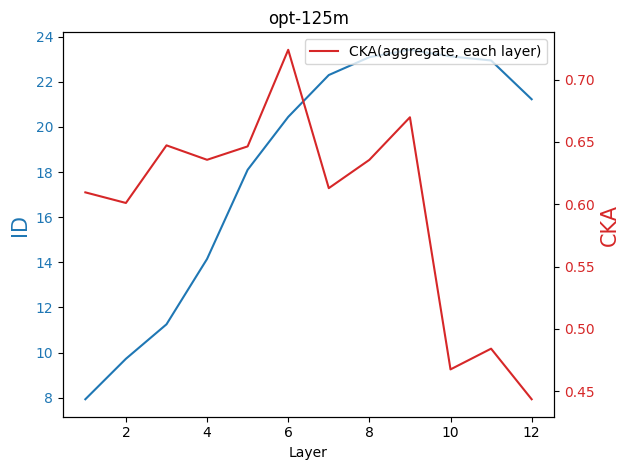

In [67]:
fig, ax1 = plt.subplots()

# Left y-axis: ID
ax1.plot(np.arange(1, len(IDS['id']) + 1), np.array(IDS['id']), label='ID', color='tab:blue')
ax1.set_xlabel('Layer')
ax1.set_ylabel('ID', color='tab:blue', fontsize=15)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Title and optional legend
plt.title(MODEL)
plt.legend()
fig.tight_layout()
plt.show()


In [68]:
# Layer order 
layer_order = sorted(range(len(IDS['id'])), key=lambda i: IDS['id'][i], reverse=False)
layer_order

[0, 1, 2, 3, 4, 5, 11, 6, 10, 7, 9, 8]

# Load features

In [5]:
# These files are located in the story_data folder of the Box
resp_dict = joblib.load("UTS03_responses.jbl") # Located in story_responses folder

with open('grids_cheap.txt', 'r') as f: # avoid oom
    grids = [title.strip() for title in f.readlines()]

# We'll build an encoding model using this set of stories for this tutorial.
test_stories = ["wheretheressmoke", 'fromboyhoodtofatherhood', 'onapproachtopluto']
train_stories = [story for story in resp_dict.keys() if story in grids and story not in test_stories]

grids = joblib.load("grids_huge.jbl") # Load TextGrids containing story annotations
trfiles = joblib.load("trfiles_huge.jbl") # Load TRFiles containing TR information

# Filter out the other stories for the tutorial
for story in list(grids):
    if story not in (train_stories + test_stories):
        del grids[story]
        del trfiles[story]

# Make datasequence for story
wordseqs = make_word_ds(grids, trfiles)

# We will extract features now
feature_extractor = FeatureExtractor(wordseqs, 'facebook/opt-125m', train_stories, test_stories)

# Convert back from dictionary to matrix
print('getting features')
os.environ["TOKENIZERS_PARALLELISM"] = "true" # multiprocessing with tokenizer in feature_extraction
feats = feature_extractor.get_features('all', seed_layer=LAYER) # N stories x L layers x d (previously N stories x d)
print('got the features')

# Training data
Rstim = np.nan_to_num(np.vstack([ridge_utils.npp.zs(feats[story][10:-5]) for story in train_stories]))

# Test data
Pstim = np.nan_to_num(np.vstack([ridge_utils.npp.zs(feats[story][trim_start:-trim_end]) for story in test_stories]))

# Add FIR delays
print('Adding FIR delays...')
delRstim = make_delayed(Rstim, delays)
delPstim = make_delayed(Pstim, delays)

# Get response data
Rresp = np.vstack([resp_dict[story] for story in train_stories]) # training Y
Presp = np.vstack([resp_dict[story][40:] for story in test_stories]) # testing Y
My_train = Rresp.astype(np.float32)
My_test = Presp.astype(np.float32)

# Get explanatory variables
Mx_train = delRstim.astype(np.float32)
Mx_test = delPstim.astype(np.float32)

INFO:accelerate.utils.modeling:We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Extracting features


100%|██████████| 183576/183576 [00:29<00:00, 6187.79it/s]


Feature extraction took 29.670814752578735 seconds on cuda:0
Deleted model
getting features


Lanczos: 100%|██████████| 98/98 [10:44<00:00,  6.57s/it] 


Convert to feature mats took 679.2260327339172 seconds
got the features
Adding FIR delays...


# Incremental PCA

In [6]:
Mx_train = Mx_train.reshape((Mx_train.shape[0], 13, Mx_train.shape[-1] // 13))

In [7]:
Mx_train = Mx_train.transpose((1, 0, 2))

In [8]:
Mx_train.shape # layers x N x dim

(13, 32402, 3072)

In [9]:
My_train.shape

(32402, 95556)

In [10]:
Mx_test = Mx_test.reshape((Mx_test.shape[0], 13, Mx_test.shape[-1] // 13)).transpose((1, 0, 2))

# Incremental Autoencoding

In [ ]:
from sklearn.decomposition import IncrementalPCA

In [71]:
DIM_BUDGET = Mx_train.shape[-1]
d = DIM_BUDGET

def squish(X):
    # X is layers x N x d
    
    ipca = IncrementalPCA(n_components=d)
    
    # init
    squished_i = X[layer_order[0]]  # N x d0
    squished_i = (squished_i - squished_i.mean(0)) / (squished_i.std(0) + 1e-8)
    
    # iterate over the rest
    for j in tqdm(range(1, len(layer_order)), desc='iterating pca'):
        layer_idx = layer_order[j]
        layer_i = X[layer_idx]  # N x d_i
        layer_i = (layer_i - layer_i.mean(0)) / (layer_i.std(0) + 1e-8) # normalize
    
        # combine current squished representation and new layer
        combined = np.concatenate([squished_i, layer_i], axis=1)  # N x (d_prev + d_i)
    
        # update PCA basis
        ipca.partial_fit(combined)
    
        # project combined manifold into shared d-dimensional subspace
        squished_i = ipca.transform(combined)

    return squished_i, ipca

# squished_i is now the N x d shared manifold representation of up-to the ith layer

def squish_test(X_test, ipca, layer_order):
    """
    Project test representations into the same shared subspace 
    learned from training via IncrementalPCA.

    X_test: np.ndarray of shape (num_layers, N_test, d_i)
    ipca: fitted IncrementalPCA object from training
    layer_order: list of layer indices used during training
    """
    
    # initialize with the first layer
    squished_i = X_test[layer_order[0]]
    squished_i = (squished_i - squished_i.mean(0)) / (squished_i.std(0) + 1e-8)
    
    for j in tqdm(range(1, len(layer_order)), desc='projecting test'):
        layer_idx = layer_order[j]
        layer_i = X_test[layer_idx]
        layer_i = (layer_i - layer_i.mean(0)) / (layer_i.std(0) + 1e-8)
        
        # combine the current squished representation with the new layer
        combined = np.concatenate([squished_i, layer_i], axis=1)
        
        # project into the learned PCA subspace (no fitting)
        squished_i = ipca.transform(combined)

    return squished_i  # shape: (N_test, d)


In [ ]:
squished_train, ipca = squish(Mx_train)

iterating pca:   9%|▉         | 1/11 [02:24<24:01, 144.11s/it]

In [ ]:
squished_test = squish_test(Mx_test, ipca, layer_order)

In [23]:
squished_test.shape # should be N x d

(790, 3072)

In [52]:
np.save('squished_opt-125m.np', squished_i)

In [24]:
np.save('squished_opt-125m-test.np', squished_test)

## What is the linearCKA (rep similarity) between the squished representation and each layer?

We want to see the max ID one best represented

In [25]:
# Evaluate: CKA between squished and new
from sklearn.metrics.pairwise import linear_kernel

def cka(X, Y):
    K = linear_kernel(X, X)
    L = linear_kernel(Y, Y)
    # Center kernels
    H = np.eye(K.shape[0]) - np.ones(K.shape[0]) / K.shape[0]
    Kc, Lc = H @ K @ H, H @ L @ H
    hsic = np.trace(Kc @ Lc)
    return hsic / (np.sqrt(np.trace(Kc @ Kc)) * np.sqrt(np.trace(Lc @ Lc)))

In [14]:
np.save('mx_train.np', Mx_train)

In [15]:
np.save('mx_test.np', Mx_test)

In [58]:
# Do this on a subset for efficiency
similarities = [cka(squished_train[:1000], Mx_train[i][:1000]) for i in tqdm(range(len(Mx_train)))]

100%|██████████| 13/13 [00:02<00:00,  4.39it/s]


In [ ]:
# Visualize layerwise similarity with the squished representation
fig, ax1 = plt.subplots()

# Left y-axis: ID
ax1.plot(np.arange(1, len(IDS['id']) + 1), np.array(IDS['id']), label='ID', color='tab:blue')
ax1.set_xlabel('Layer')
ax1.set_ylabel('ID', color='tab:blue', fontsize=15)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right y-axis: CKA
ax2 = ax1.twinx()
ax2.plot(np.arange(1, len(IDS['id']) + 1), similarities[1:], label='CKA(aggregate, each layer)', color='tab:red')
ax2.set_ylabel('CKA', color='tab:red', fontsize=15)
ax2.tick_params(axis='y', labelcolor='tab:red')

# Title and optional legend
plt.title(MODEL)
plt.legend()
fig.tight_layout()
plt.show()

# Linear regression

In [35]:
print('Computing projection maps on train data')
_, projection_map_y = down_project(My_train, project_type='pca', n_evecs=250)
up_projection_map_y = projection_map_y.inverse_transform
print("Bootstrap ridge")
# projection_map_y = 'pca'

Computing projection maps on train data
Bootstrap ridge


In [36]:
# Do the linear regression
# Bootstrap parameters
alphas = np.logspace(1, 4, 15) # Equally log-spaced ridge parameters between 10 and 10000.
nboots = 3 # Number of cross-validation ridge regression runs. You can lower this number to increase speed.
chunklen = 20
nchunks = int(len(My_train) * 0.25 / chunklen)
n_evecs = 250
y_projection = 'pca'

# Use RJ's bootstrap ridge code modified to handle projection
wt, corr, best_alpha, bootstrap_corrs, valinds = bootstrap_ridge_with_y_projection(
                                                    squished_train, My_train, squished_test, My_test,
                                                    alphas, nboots, chunklen, nchunks,
                                                    up_projection_map_y, projection_map_y,
                                                    y_projection=y_projection,
                                                )
if type(best_alpha) != list:
    best_alpha = best_alpha.tolist()
if type(valinds) != list:
    valinds = valinds.tolist()
if type(bootstrap_corrs) != list:
    bootstrap_corrs = bootstrap_corrs.squeeze() # 1 x nvox x 1
    bootstrap_corrs = bootstrap_corrs.tolist()
if type(corr) != list:
    corr = corr.tolist()

results = {
    'params': {'model': 'opt-125m'},
    'corr': list(corr), # nvox
    'bscorrs': list(bootstrap_corrs),
    'val_indices': list(valinds),
    'alphas': best_alpha # scalar
}

INFO:ridge_corr:Starting bootstrap with 3 boots, 15 alphas
INFO:ridge_corr:Data: 32402 timepoints, 95556 voxels
INFO:ridge_corr:Projection: 250 components, type: pca
INFO:ridge_corr:Bootstrap 1/3
INFO:ridge_corr:Using alpha=10.000000 (normalized: 10.000000) for 250 components
INFO:ridge_corr:Alpha 10.000000: mean_corr=0.05759, max_corr=0.58988
INFO:ridge_corr:Using alpha=26.826958 (normalized: 26.826958) for 250 components
INFO:ridge_corr:Alpha 26.826958: mean_corr=0.05961, max_corr=0.59409
INFO:ridge_corr:Using alpha=43.939706 (normalized: 43.939706) for 250 components
INFO:ridge_corr:Alpha 43.939706: mean_corr=0.06206, max_corr=0.59844
INFO:ridge_corr:Using alpha=71.968567 (normalized: 71.968567) for 250 components
INFO:ridge_corr:Alpha 71.968567: mean_corr=0.06566, max_corr=0.60342
INFO:ridge_corr:Using alpha=117.876863 (normalized: 117.876863) for 250 components
INFO:ridge_corr:Alpha 117.876863: mean_corr=0.07012, max_corr=0.60747
INFO:ridge_corr:Using alpha=193.069773 (normalized:

NameError: name 'args' is not defined

In [38]:
# Save
save_dir = f'/home/echeng/encoding-models/results/{MODEL}'
os.makedirs(save_dir, exist_ok=True)

with open(f'{save_dir}/results_squished_n_layers_13_seed_layer_8_y_rank_250_pca_ridge.json', 'w') as f:
    json.dump(results, f)